In [14]:
import bioframe as bf
import openpyxl
import pandas as pd

import numpy as np
import bbi
import matplotlib.pyplot as plt

In [22]:
RNA_seq_annot_for_bbi = pd.read_csv('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/Changed_tss_expressed_genes_files/ATAC_RNA_annot_for_bbi_no0.bed', sep='\t')

genes_new_unexpressed = RNA_seq_annot_for_bbi[RNA_seq_annot_for_bbi['tpm_ctr'] < 0.001]
genes_new_low_expressed = RNA_seq_annot_for_bbi[(RNA_seq_annot_for_bbi['tpm_ctr'] > 0.001) & (RNA_seq_annot_for_bbi['tpm_ctr'] < 0.1)]
genes_new_mid_expressed = RNA_seq_annot_for_bbi[(RNA_seq_annot_for_bbi['tpm_ctr'] > 0.1) & (RNA_seq_annot_for_bbi['tpm_ctr'] < 10)]
genes_new_highly_expressed = RNA_seq_annot_for_bbi[RNA_seq_annot_for_bbi['tpm_ctr'] > 10]


/tmp/ipykernel_32060/761713662.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  RNA_seq_annot_for_bbi = pd.read_csv('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/Changed_tss_expressed_genes_files/ATAC_RNA_annot_for_bbi_no0.bed', sep='\t')


In [24]:
print('genes_unexpressed:', len(genes_unexpressed))
print('genes_low_expressed:', len(genes_low_expressed))
print('genes_midlow_expressed:', len(genes_midlow_expressed))
print('genes_midhigh_expressed:', len(genes_midhigh_expressed))
print('genes_high_expressed:', len(genes_high_expressed))

genes_unexpressed: 19398
genes_low_expressed: 1663
genes_midlow_expressed: 16947
genes_midhigh_expressed: 15010
genes_high_expressed: 1697


In [30]:
dfs = [genes_low_expressed, genes_midlow_expressed, genes_midhigh_expressed, genes_high_expressed]
genes_expressed = pd.concat(dfs, axis=0, ignore_index=True)

genes_expressed = genes_expressed.sort_values(by='tpm_ctr', ascending=True)

In [31]:
bigWig_control_consensus = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp_consensus = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [32]:
def oriented_cov_by_expression(
    df,
    bw_control,
    bw_exp,
    bins=200,
    summary="sum"
):
    """
    Extract control and experimental bigWig coverage around promoters.

    Rows are sorted by control TPM in ascending order.
    Minus-strand profiles are reversed so all genes have the same
    transcriptional orientation.
    """

    required_columns = {
        "chrom", "str_win2", "end_win2", "strand", "tpm_ctr"
    }

    missing = required_columns.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Sort genes by control expression
    df_sorted = (
        df
        .sort_values("tpm_ctr", ascending=True)
        .reset_index(drop=True)
        .copy()
    )

    plus_mask = df_sorted["strand"].eq("+").to_numpy()
    minus_mask = df_sorted["strand"].eq("-").to_numpy()

    # Preallocate matrices in final TPM-sorted order
    cov_control = np.full((len(df_sorted), bins), np.nan)
    cov_exp = np.full((len(df_sorted), bins), np.nan)

    # Plus-strand genes
    plus = df_sorted.loc[plus_mask]

    cov_control[plus_mask] = bw_control.stackup(
        plus["chrom"],
        plus["str_win2"],
        plus["end_win2"],
        bins=bins,
        summary=summary
    )

    cov_exp[plus_mask] = bw_exp.stackup(
        plus["chrom"],
        plus["str_win2"],
        plus["end_win2"],
        bins=bins,
        summary=summary
    )

    # Minus-strand genes, reversed left-to-right
    minus = df_sorted.loc[minus_mask]

    cov_control[minus_mask] = bw_control.stackup(
        minus["chrom"],
        minus["str_win2"],
        minus["end_win2"],
        bins=bins,
        summary=summary
    )[:, ::-1]

    cov_exp[minus_mask] = bw_exp.stackup(
        minus["chrom"],
        minus["str_win2"],
        minus["end_win2"],
        bins=bins,
        summary=summary
    )[:, ::-1]

    return cov_control, cov_exp, df_sorted

In [33]:
cov_control, cov_exp, genes_sorted = oriented_cov_by_expression(
    genes_expressed, 
    bigWig_control_consensus, 
    bigWig_exp_consensus, 
    bins=200
)

In [34]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 20 

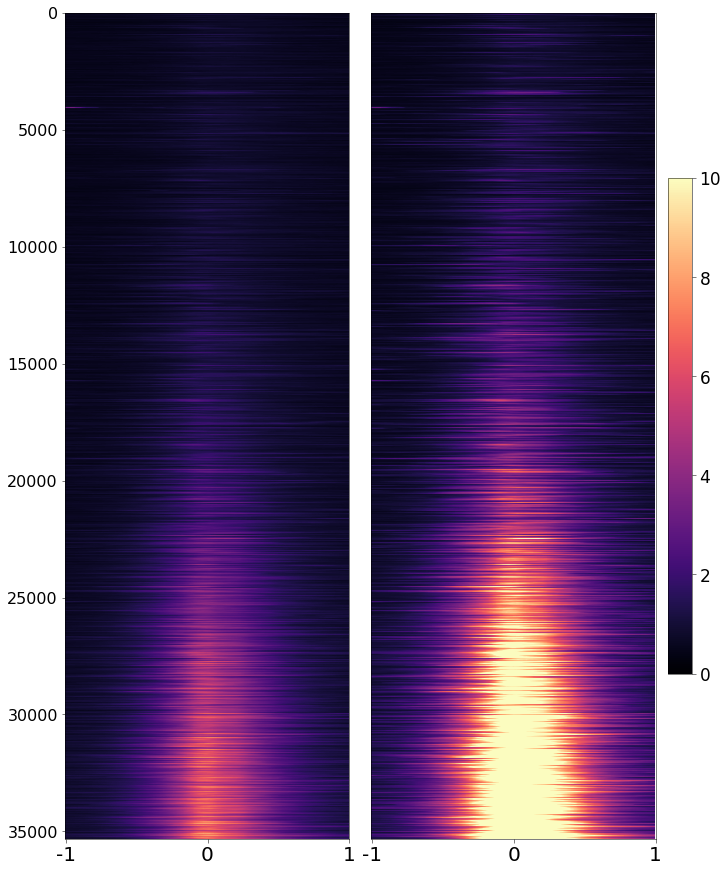

In [35]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(10, 12),              # width, height in inches
    gridspec_kw={'wspace': 0.01},  # reduce space between subplots
    constrained_layout=True
)

# CONTROL plot (ax1)
# ax1.set_title('CONTROL', fontsize=20)
im1 = ax1.imshow(cov_control, cmap="magma", aspect="auto", vmax=10, vmin=0)
ax1.set_xticks([0, 100, 200], [-1, 0, +1])
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=16)

# Add colorbar to ax1
cbar = fig.colorbar(im1, ax=ax2, shrink=0.6, pad=0.02, location='right')
# cbar.set_label("ATAC-seq coverage, 10bp bins", fontsize=20)
cbar.ax.tick_params(labelsize=17)

cbar.ax.tick_params(width=0.5)  # tick line width
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.5)
    
# CHD1 cKO plot (ax2)
# ax2.set_title('CHD1 cKO', fontsize=20)
im2 = ax2.imshow(cov_exp, cmap="magma", aspect="auto", vmax=10, vmin=0)
ax2.set_xticks([0, 100, 200], [-1, 0, +1])
ax2.tick_params(axis='x', labelsize=20)
ax2.set_yticks([])

for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)
    ax.tick_params(width=0.5) 

plt.show()

#plt.savefig("Stackup_promoters_2kb_expression_sorted_vmax10.pdf", dpi=300, bbox_inches="tight", pad_inches=1)